Number of detected tracks: 19
First application position (px from left edge): 85.9
First application position (mm from left edge): 7.278
Average distance between tracks (mm): 10.167


<Figure size 1500x1000 with 0 Axes>

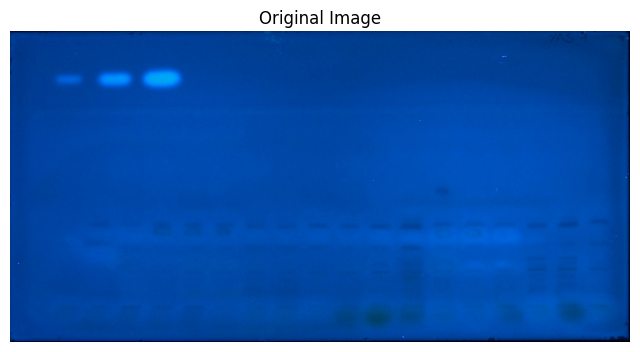

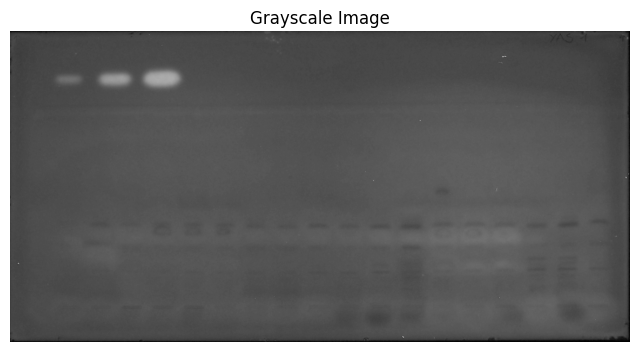

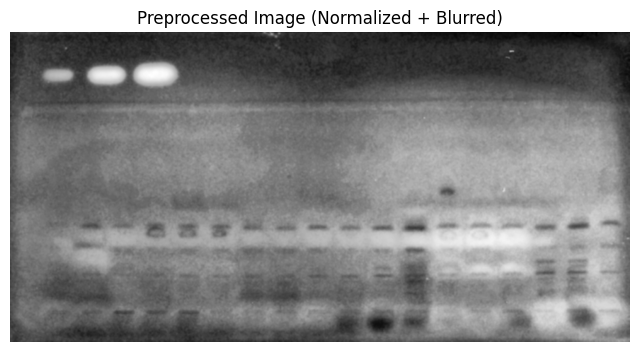

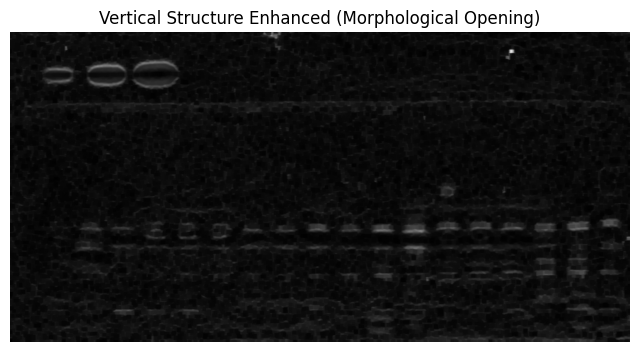

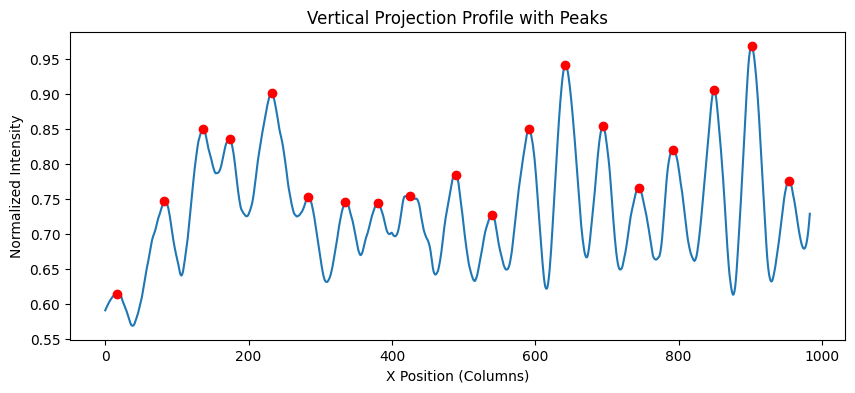

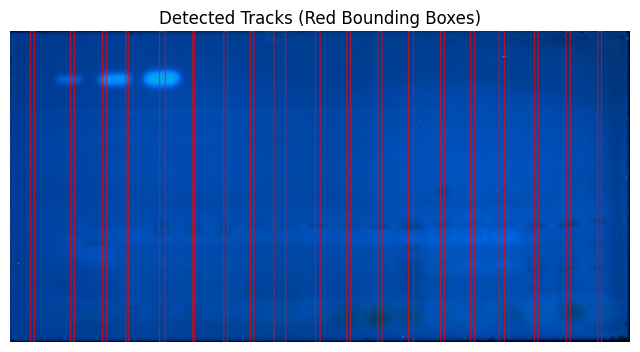

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths, savgol_filter

# ============================
# STEP 1 — STANDARDIZE INPUT
# ============================

def preprocess_image(image_path, target_width=1024, crop_percent=0.02):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize
    h, w = gray.shape
    scale = target_width / w
    new_h = int(h * scale)
    resized = cv2.resize(gray, (target_width, new_h))

    # ============================
    #  Crop borders to remove noise
    # ============================
    h2, w2 = resized.shape

    crop_x = int(w2 * (crop_percent ))
    crop_y = int(h2 * crop_percent)

    cropped = resized[
        crop_y : h2 - crop_y,
        crop_x : w2 - crop_x
    ]

    # ============================
    # CLAHE (contrast enhancement)
    # ============================
    clahe = cv2.createCLAHE(
        clipLimit=5.0,
        tileGridSize=(20, 1)
    )
    equalized = clahe.apply(cropped)

    # Optional smoothing
    blurred = cv2.GaussianBlur(equalized, (5, 5), 0)

    return img, gray, blurred, scale, crop_x


# ====================================
# STEP 2 — ENHANCE VERTICAL STRUCTURES
# ====================================

# def enhance_vertical_structures(image):
#     # Invert image (important for dark tracks)
#     inverted = 255 - image

#     # Vertical kernel
#     kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 50))

#     # Opening on inverted image
#     opened = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)

#     return opened
def enhance_vertical_structures(image):

    # Invert image (helps when tracks are dark)
    inverted = 255 - image

    # Apply Sobel filter
    sobelx = cv2.Sobel(
        inverted,
        cv2.CV_64F,
        0,   # dx
        1,   # dy
        ksize=5
    )

    # Convert to absolute values
    sobelx = np.absolute(sobelx)

    # Normalize to 0–255
    sobelx = cv2.normalize(sobelx, None, 0, 255, cv2.NORM_MINMAX)

    # Convert to uint8
    sobelx = sobelx.astype(np.uint8)

    # -----------------------------
    # 🔹 Convert to binary mask
    # -----------------------------
    _, mask = cv2.threshold(
        sobelx,
        40,          # threshold value (tune this)
        255,
        cv2.THRESH_BINARY
    )

    # -----------------------------
    # 🔹 Morphological Closing
    # -----------------------------
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
    closed = cv2.morphologyEx(sobelx, cv2.MORPH_CLOSE, kernel)

    return closed

# ====================================
# STEP 3 — VERTICAL PROJECTION + PEAKS
# ====================================

def detect_tracks(enhanced_image):
    # Column-wise projection
    projection = np.sum(enhanced_image, axis=0)

    # Normalize
    projection = projection / np.max(projection)

    smoothed_projection = savgol_filter(
        projection,
        window_length=41,   # must be odd
        polyorder=3      # adjust if needed
    )



    # Now directly find peaks on inverted signal

    # ----------------------------
    # 🔥 Adaptive parameters
    # ----------------------------
    std_val = np.std(smoothed_projection)

    prominence = 0.1 * std_val   # key parameter
    # prominence = np.percentile(smoothed_projection, 75) * 0.5
    # prominence = max(
    # 0.2 * np.std(smoothed_projection),
    # 0.3 * np.percentile(smoothed_projection, 75)
# )
    distance = len(projection) // 30

    # ----------------------------
    # Peak detection
    # ----------------------------
    peaks, properties = find_peaks(
        smoothed_projection,
        prominence=prominence,
        distance=distance
    )

    # ----------------------------
    # Adaptive band width
    # ----------------------------
    results = peak_widths(
        smoothed_projection,
        peaks,
        rel_height=0.05   # more stable than 0.05
    )

    left_ips = results[2]
    right_ips = results[3]

    return peaks, smoothed_projection ,left_ips, right_ips




# ====================================
# STEP 4 — DRAW RED BOXES
# ====================================

# def draw_track_boxes(original_img, peaks, scale, crop_x):
#     img_copy = original_img.copy()

#     peaks_resized = peaks + crop_x
#     peaks_original = np.sort(peaks_resized / scale)

#     for i in range(len(peaks_original) - 1):

#         x1 = int(peaks_original[i])
#         x2 = int(peaks_original[i+1])

#         y1 = 0
#         y2 = img_copy.shape[0]

#         cv2.rectangle(img_copy, (x1,y1), (x2,y2), (0,0,255), 2)

#         center_x = int((x1+x2)/2)

#         cv2.putText(
#             img_copy,
#             f"B{i+1}",
#             (center_x-10,40),
#             cv2.FONT_HERSHEY_SIMPLEX,
#             0.8,
#             (0,0,255),
#             2
#         )

#     return img_copy
def draw_track_boxes(original_img, left_ips, right_ips, scale, crop_x):
    img_copy = original_img.copy()

    for left, right in zip(left_ips, right_ips):

        # Convert from cropped coordinates → original coordinates
        x1 = int((left + crop_x) / scale)
        x2 = int((right + crop_x) / scale)

        y1 = 0
        y2 = img_copy.shape[0]

        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0,0,255), 2)

    return img_copy


# ============================
# MAIN PIPELINE
# ============================

image_path = "download/3_33_2_5_2_34_3_1_1_171.tif"  # <-- replace with your image
# image_path = "Sugar.jpg"  # <-- replace with your image

original_img, gray_img, preprocessed, scale, crop_x = preprocess_image(image_path)

enhanced = enhance_vertical_structures(preprocessed)

peaks, projection, left_ips, right_ips = detect_tracks(enhanced)

result = draw_track_boxes(original_img, left_ips, right_ips, scale, crop_x)

print("Number of detected tracks:", len(peaks))

# ----------------------------
# Track spacing in millimeters
# ----------------------------
# Provide the real-world width (in mm) represented by the FULL original image width.
# Example: if the camera sees 60 mm across the full image width, set known_image_width_mm = 60.0
known_image_width_mm = 200.0  # <-- set this (float, in mm)

mm_per_pixel = None if known_image_width_mm is None else float(known_image_width_mm) / float(original_img.shape[1])


# Prefer band centers computed from detected band edges (more stable than peak index)
centers_cropped = (left_ips + right_ips) / 2.0  # in resized+cropspace pixels
centers_original_px = np.sort((centers_cropped + crop_x) / scale)  # in original-image pixels

if len(centers_original_px) >= 1:
    first_application_pos_px = float(centers_original_px[0])
    print(f"First application position (px from left edge): {first_application_pos_px:.1f}")

    if mm_per_pixel is not None:
        first_application_pos_mm = first_application_pos_px * mm_per_pixel
        print(f"First application position (mm from left edge): {first_application_pos_mm:.3f}")
    else:
        print("First application position (mm): N/A (set known_image_width_mm first)")
else:
    print("First application position: N/A (no tracks detected)")


# Average distance between tracks (center-to-center)
if len(peaks) > 1 and mm_per_pixel is not None:
    peak_positions_original_px = np.sort(peaks.astype(float) / scale)
    track_distances_px = np.diff(peak_positions_original_px)
    avg_distance_mm = float(np.mean(track_distances_px) * mm_per_pixel)
    print(f"Average distance between tracks (mm): {avg_distance_mm:.3f}")
elif len(peaks) <= 1:
    print("Average distance between tracks (mm): N/A (need at least 2 tracks)")
else:
    print("Average distance between tracks (mm): N/A (set known_image_width_mm first)")


# ============================
# VISUALIZATION SECTION
# ============================

plt.figure(figsize=(15, 10))

# 1️⃣ Original Image
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.show()


# 2️⃣ Grayscale
plt.figure(figsize=(8, 6))
plt.imshow(gray_img, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()


# 3️⃣ Preprocessed (Blurred + Normalized)
plt.figure(figsize=(8, 6))
plt.imshow(preprocessed, cmap='gray')
plt.title("Preprocessed Image (Normalized + Blurred)")
plt.axis("off")
plt.show()


# 4️⃣ Enhanced Vertical Structures
plt.figure(figsize=(8, 6))
plt.imshow(enhanced, cmap='gray')
plt.title("Vertical Structure Enhanced (Morphological Opening)")
plt.axis("off")
plt.show()


# 5️⃣ Projection Profile
plt.figure(figsize=(10, 4))
plt.plot(projection)
plt.plot(peaks, projection[peaks], "ro")
plt.title("Vertical Projection Profile with Peaks")
plt.xlabel("X Position (Columns)")
plt.ylabel("Normalized Intensity")
plt.show()


# 6️⃣ Final Result with Red Boxes
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Detected Tracks (Red Bounding Boxes)")
plt.axis("off")
plt.show()

# to-do 
- run the script over all the images and extract and save bands in the each foder
- making the cluster of the bands 

In [8]:
image_folder = "download"  # <-- replace with your image


# running over all images 

In [10]:
import os

def save_bands(original_img, left_ips, right_ips, scale, crop_x, output_dir):

    h = original_img.shape[0]

    for i, (left, right) in enumerate(zip(left_ips, right_ips)):

        # Convert to original coordinates
        x1 = int((left + crop_x) / scale)
        x2 = int((right + crop_x) / scale)

        # Safety clipping
        x1 = max(0, x1)
        x2 = min(original_img.shape[1], x2)

        # Crop band
        band = original_img[:, x1:x2]

        # Save
        band_path = os.path.join(output_dir, f"band_{i+1}.png")
        cv2.imwrite(band_path, band)

In [15]:
import os
from glob import glob

input_folder = "download"
output_root = "output_bands_change_point"

os.makedirs(output_root, exist_ok=True)

image_paths = glob(os.path.join(input_folder, "*.*"))

for image_path in image_paths:

    print(f"\nProcessing: {image_path}")

    # Get image name without extension
    image_name = os.path.splitext(os.path.basename(image_path))[0]

    # Create folder for this image
    output_dir = os.path.join(output_root, image_name)
    os.makedirs(output_dir, exist_ok=True)

    # ------------------------
    # Run your pipeline
    # ------------------------
    original_img, gray_img, preprocessed, scale, crop_x = preprocess_image(image_path)

    enhanced = enhance_vertical_structures(preprocessed)

    peaks, projection, left_ips, right_ips = detect_tracks(enhanced)

    order = np.argsort(left_ips)
    left_ips = left_ips[order]
    right_ips = right_ips[order]
    peaks = peaks[order]

# ============================
# 🔥 MERGE DOUBLE PEAKS
# ============================
    left_ips, right_ips = merge_close_peaks(
        peaks,
        left_ips,
        right_ips,
        projection,
        merge_threshold=30   # 🔥 FIXED
    )

    result = draw_track_boxes(original_img, left_ips, right_ips, scale, crop_x)

    print("Number of detected tracks:", len(peaks))

    # ------------------------
    # Save bands
    # ------------------------
    save_bands(original_img, left_ips, right_ips, scale, crop_x, output_dir)

    # ------------------------
    # Save result image
    # ------------------------
    result_path = os.path.join(output_dir, "result.png")
    cv2.imwrite(result_path, result)

print("\n✅ All images processed.")


Processing: download/9_50_2_4_2_11_1_2_1_105.tif
Number of detected tracks: 24

Processing: download/1_21_1_5_2_33_3_1_1_192.tif
Number of detected tracks: 14

Processing: download/1_1_1_5_2_48_2_1_1_199.tif
Number of detected tracks: 14

Processing: download/1_7_1_5_2_33_3_3_1_179.tif
Number of detected tracks: 16

Processing: download/3_33_2_5_2_53_2_1_1_159.tif
Number of detected tracks: 18

Processing: download/4_19_2_5_2_38_3_1_1_141.tif
Number of detected tracks: 18

Processing: download/4_19_2_5_2_33_3_3_3_132.tif
Number of detected tracks: 13

Processing: download/3_33_2_5_2_1_1_1_1_161.tif
Number of detected tracks: 18

Processing: download/9_50_2_5_2_2_3_2_2_112.tif
Number of detected tracks: 13

Processing: download/3_33_2_5_2_38_3_1_1_170.tif
Number of detected tracks: 13

Processing: download/4_19_2_5_2_38_3_1_1_140.tif
Number of detected tracks: 16

Processing: download/1_7_1_5_2_1_3_3_2_177.tif
Number of detected tracks: 14

Processing: download/1_7_1_5_2_1_3_1_1_187.ti

### Clustering on the images 

Using cache found in /Users/maneet/.cache/torch/hub/facebookresearch_dinov2_main


✅ Images saved into cluster folders!


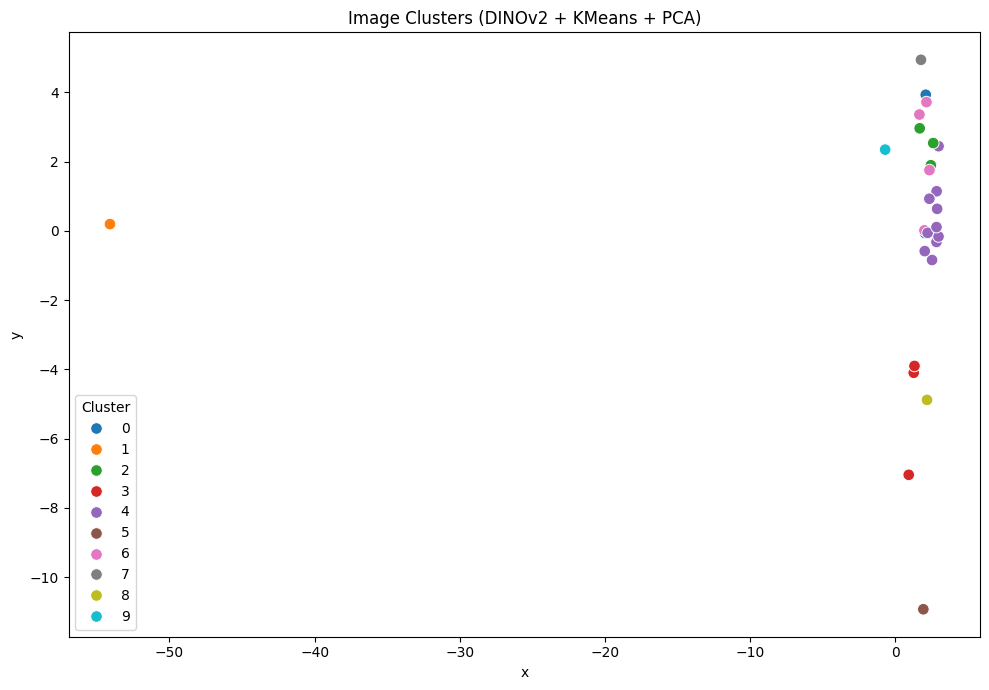

In [37]:
from pathlib import Path
import numpy as np
import torch
import torchvision.transforms as T
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import shutil

# مسیر تصاویر
image_dir = Path("output_bands/9_50_2_4_2_2_3_2_1_104")
output_dir = Path("output_cluster")
output_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 1. Load DINOv2 model
# -----------------------------
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
model.eval()
device = "cpu"
model.to(device)

# -----------------------------
# 2. Image preprocessing
# -----------------------------
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
])

# -----------------------------
# 3. Extract embeddings
# -----------------------------
embeddings = []
image_paths = []

for img_path in image_dir.glob("*"):
    try:
        img = Image.open(img_path).convert("RGB")
        img_tensor = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            feat = model(img_tensor)

        embeddings.append(feat.squeeze().cpu().numpy())
        image_paths.append(img_path)

    except Exception as e:
        print(f"Skipping {img_path}: {e}")

embeddings = np.array(embeddings)

# -----------------------------
# 4. KMeans clustering
# -----------------------------
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(embeddings)

# -----------------------------
# 5. Save images into cluster folders
# -----------------------------
for i in range(n_clusters):
    (output_dir / f"{i}").mkdir(parents=True, exist_ok=True)

for img_path, label in zip(image_paths, labels):
    target_path = output_dir / f"{label}" / img_path.name
    shutil.copy(img_path, target_path)

print("✅ Images saved into cluster folders!")

# -----------------------------
# 6. PCA for visualization
# -----------------------------
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

# -----------------------------
# 7. Scatter plot (Seaborn)
# -----------------------------
df = pd.DataFrame({
    "x": reduced[:, 0],
    "y": reduced[:, 1],
    "cluster": labels
})

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="x",
    y="y",
    hue="cluster",
    palette="tab10",
    s=70
)

plt.title("Image Clusters (DINOv2 + KMeans + PCA)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

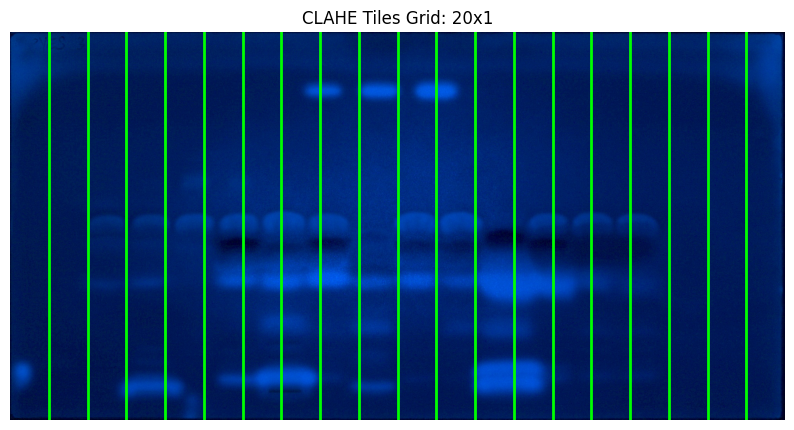

In [4]:
import cv2
import matplotlib.pyplot as plt

# Load your image (replace with your path)
image_path = 'download/4_19_2_5_2_33_3_1_1_127.tif'
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

# CLAHE tile grid (visualization only)
cols, rows = 20, 1  # corresponds to tileGridSize=(cols, rows)
h, w = img_bgr.shape[:2]

tile_w = w / float(cols)
tile_h = h / float(rows)

# Convert BGR -> RGB for Matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img_rgb)
ax.set_title(f"CLAHE Tiles Grid: {cols}x{rows}")
ax.set_axis_off()

# Draw grid lines with Matplotlib
for i in range(1, cols):
    x = i * tile_w
    ax.axvline(x=x, color='lime', linewidth=2)
for j in range(1, rows):
    y = j * tile_h
    ax.axhline(y=y, color='lime', linewidth=2)

# Optional: save the figure
fig.savefig('tiles_visualized_matplotlib.png', dpi=150, bbox_inches='tight')
plt.show()

Number of detected tracks: 19
First band position: 1197.0px | 101.35 mm


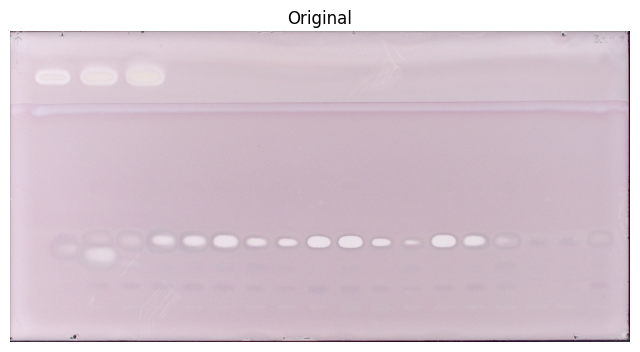

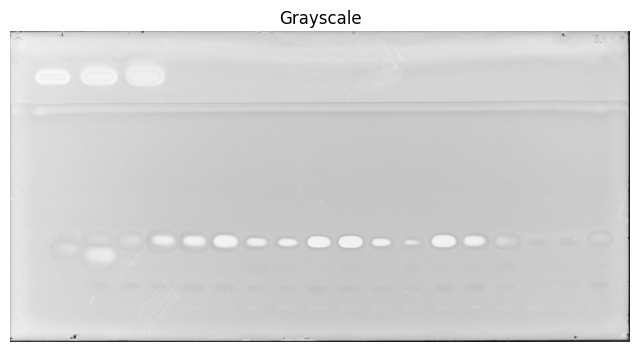

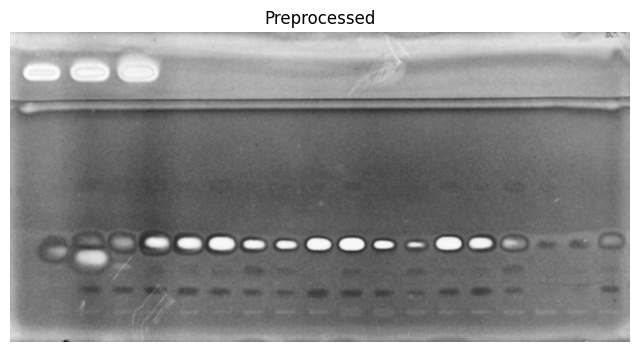

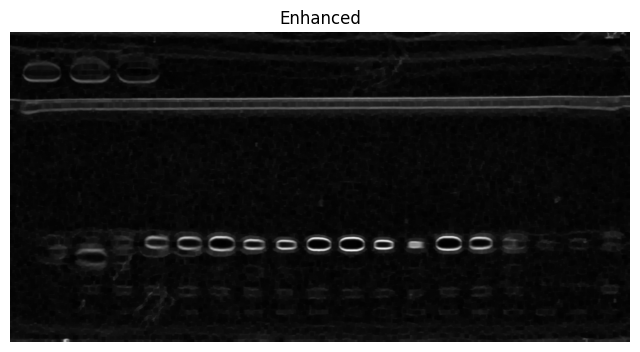

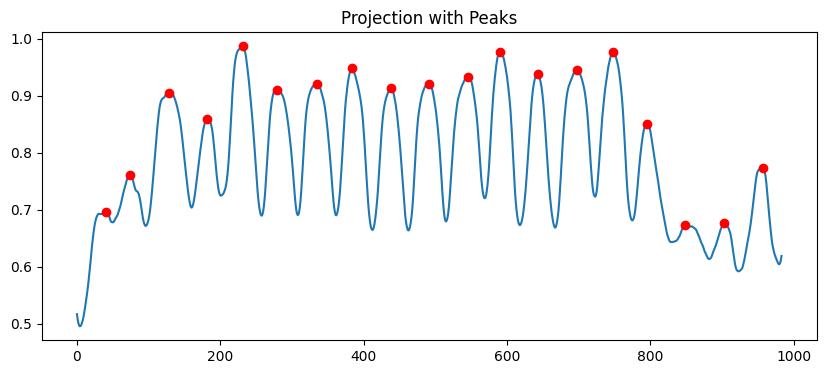

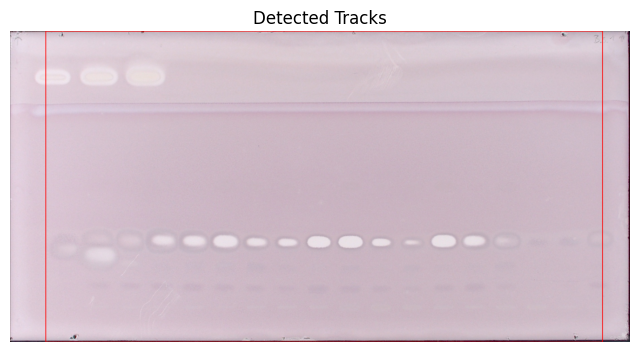

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths, savgol_filter
import ruptures as rpt


# ============================
# STEP 1 — STANDARDIZE INPUT
# ============================

def preprocess_image(image_path, target_width=1024, crop_percent=0.02):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize
    h, w = gray.shape
    scale = target_width / w
    new_h = int(h * scale)
    resized = cv2.resize(gray, (target_width, new_h))

    # Crop borders
    h2, w2 = resized.shape
    crop_x = int(w2 * crop_percent)
    crop_y = int(h2 * crop_percent)

    cropped = resized[
        crop_y : h2 - crop_y,
        crop_x : w2 - crop_x
    ]

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(20, 1))
    equalized = clahe.apply(cropped)

    blurred = cv2.GaussianBlur(equalized, (5, 5), 0)

    return img, gray, blurred, scale, crop_x


# ====================================
# STEP 2 — ENHANCE VERTICAL STRUCTURES
# ====================================

def enhance_vertical_structures(image):

    inverted = 255 - image

    sobelx = cv2.Sobel(inverted, cv2.CV_64F, 0, 1, ksize=5)
    sobelx = np.absolute(sobelx)
    sobelx = cv2.normalize(sobelx, None, 0, 255, cv2.NORM_MINMAX)
    sobelx = sobelx.astype(np.uint8)

    _, mask = cv2.threshold(sobelx, 40, 255, cv2.THRESH_BINARY)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    closed = cv2.morphologyEx(sobelx, cv2.MORPH_CLOSE, kernel)

    return closed


# ====================================
# STEP 3 — DETECTION (IMPROVED)
# ====================================

def detect_tracks(enhanced_image):

    # Projection
    projection = np.sum(enhanced_image, axis=0)
    projection = projection / np.max(projection)

    # ============================
    # 🔥 ENSEMBLE SMOOTHING
    # ============================
    windows = [11, 21, 31, 41, 51]  # multiple odd window sizes
    smoothed_list = [
        savgol_filter(projection, w, 3) for w in windows
    ]
    smoothed_projection = np.mean(smoothed_list, axis=0)

    # ============================
    # 🔥 CHANGE POINT DETECTION
    # ============================
    model = rpt.Pelt(model="rbf").fit(smoothed_projection)
    change_points = model.predict(pen=5)
    change_points = change_points[:-1]

    # ============================
    # 🔥 SEGMENT-WISE PEAK DETECTION
    # ============================
    peaks_all = []
    left_ips_all = []
    right_ips_all = []

    start = 0

    for end in change_points + [len(smoothed_projection)]:

        segment = smoothed_projection[start:end]

        if len(segment) < 10:
            start = end
            continue

        std_val = np.std(segment)
        prominence = max(0.01, 0.1 * std_val)
        distance = max(5, len(segment) // 5)

        peaks, _ = find_peaks(
            segment,
            prominence=prominence,
            distance=distance
        )

        if len(peaks) > 0:
            widths = peak_widths(segment, peaks, rel_height=0.05)

            peaks_all.extend(peaks + start)
            left_ips_all.extend(widths[2] + start)
            right_ips_all.extend(widths[3] + start)

        start = end

    return (
        np.array(peaks_all),
        smoothed_projection,
        np.array(left_ips_all),
        np.array(right_ips_all)
    )


# ====================================
# STEP 4 — DRAW BOXES
# ====================================

def draw_track_boxes(original_img, left_ips, right_ips, scale, crop_x):
    img_copy = original_img.copy()

    for left, right in zip(left_ips, right_ips):
        x1 = int((left + crop_x) / scale)
        x2 = int((right + crop_x) / scale)

        y1 = 0
        y2 = img_copy.shape[0]

        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0,0,255), 2)

    return img_copy

def merge_close_peaks(peaks, left_ips, right_ips, projection, merge_threshold=10):
    merged_left = []
    merged_right = []

    i = 0
    n = len(peaks)

    while i < n:
        current_left = left_ips[i]
        current_right = right_ips[i]

        j = i + 1

        # Merge while overlapping or very close
        while j < n and left_ips[j] <= current_right + merge_threshold:
            current_right = max(current_right, right_ips[j])
            j += 1

        merged_left.append(current_left)
        merged_right.append(current_right)

        i = j

    return np.array(merged_left), np.array(merged_right)
# ============================
# MAIN PIPELINE
# ============================

image_path = "download/3_33_2_5_1_41_1_1_1_151.tif"

original_img, gray_img, preprocessed, scale, crop_x = preprocess_image(image_path)

enhanced = enhance_vertical_structures(preprocessed)

peaks, projection, left_ips, right_ips = detect_tracks(enhanced)

order = np.argsort(left_ips)
left_ips = left_ips[order]
right_ips = right_ips[order]
peaks = peaks[order]

# ============================
# 🔥 MERGE DOUBLE PEAKS
# ============================
left_ips, right_ips = merge_close_peaks(
    peaks,
    left_ips,
    right_ips,
    projection,
    merge_threshold=50   # 🔥 FIXED
)

result = draw_track_boxes(original_img, left_ips, right_ips, scale, crop_x)

print("Number of detected tracks:", len(peaks))


# ============================
# METRICS
# ============================

known_image_width_mm = 200.0

mm_per_pixel = known_image_width_mm / original_img.shape[1]

centers = (left_ips + right_ips) / 2
centers_original = np.sort((centers + crop_x) / scale)

if len(centers_original) > 0:
    first_pos_px = centers_original[0]
    first_pos_mm = first_pos_px * mm_per_pixel

    print(f"First band position: {first_pos_px:.1f}px | {first_pos_mm:.2f} mm")

if len(centers_original) > 1:
    distances_px = np.diff(centers_original)
    avg_mm = np.mean(distances_px) * mm_per_pixel
    print(f"Average spacing: {avg_mm:.2f} mm")


# ============================
# VISUALIZATION
# ============================

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")
plt.show()

plt.figure(figsize=(8,6))
plt.imshow(gray_img, cmap='gray')
plt.title("Grayscale")
plt.axis("off")
plt.show()

plt.figure(figsize=(8,6))
plt.imshow(preprocessed, cmap='gray')
plt.title("Preprocessed")
plt.axis("off")
plt.show()

plt.figure(figsize=(8,6))
plt.imshow(enhanced, cmap='gray')
plt.title("Enhanced")
plt.axis("off")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(projection)
plt.plot(peaks, projection[peaks], "ro")
plt.title("Projection with Peaks")
plt.show()

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Detected Tracks")
plt.axis("off")
plt.show()